## IsTheWorldReadyForTheNextPandemic - Mini Project
### Project handled by Liza, Ravit, Hagit and Hodaya

**This notebook includes running of a comprehensive Exploratory Data Analysis (EDA) on base dataSet ready for modeling.**



---
## Part 1 · Setup, data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Core imports.
import numpy as np
np.random.seed(42)  # For reproducibility
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the path where your DataSet CSVs located.
data_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'


##Merge #1: The "Country Profile" merge
This merge combines the primary static reference tables (Country_Ind_md.csv, health_Ind_md.csv and demographics_Ind_md.csv) using a standard Inner Join on their shared primary/foreign key field: location_key.

**What this brings**: This creates a comprehensive master list of every region’s socio-economic and physical health profile

**Exportable Info**: User can export data showing how physicians per 1000 or health expenditure correlates with population density and the Human Development Index

In [ ]:
# ==========================================================================
# Merge Country_Ind_md.csv, health_Ind_md.csv and demographics_Ind_md.csv
# ==========================================================================

"""
The subregion fields are entirely empty (NaN or empty commas).
Merging on all those blank subregion columns is unnecessary, and location_key is the ideal single primary key representing the country.
To avoid column clutter (such as country_name_x, country_name_y, etc.) when joining only on location_key,
there is a need to clean up the datasets before merging [keeping these descriptive columns in just one table (the Country table)
and drop them from the Demographics and Health tables prior to the merge]
"""

import os
import pandas as pd

# 1. Define directory paths
shared_location = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'

country_path = os.path.join(shared_location, 'Country_Ind_md.csv')
demographics_path = os.path.join(shared_location, 'demographics_Ind_md.csv')
health_path = os.path.join(shared_location, 'health_Ind_md.csv')
output_path = os.path.join(shared_location, 'health_Demog_Ind_md.csv')

# 2. Load the datasets
print(f"Loading source tables from: {shared_location}")
df_country = pd.read_csv(country_path)
df_demog = pd.read_csv(demographics_path)
df_health = pd.read_csv(health_path)

# 3. Deduplicate fields before merging
# We keep the geographic details (country name, code, subregions, aggregation level)
# ONLY in df_country. We drop them from demographics and health to prevent "_x/_y" suffixes.
columns_to_drop = [
    'country_code', 'country_name',
    'subregion1_code', 'subregion1_name',
    'subregion2_code', 'subregion2_name',
    'aggregation_level'
]

# Drop redundant columns from demographics and health (keeping only location_key)
df_demog_clean = df_demog.drop(columns=columns_to_drop, errors='ignore')
df_health_clean = df_health.drop(columns=columns_to_drop, errors='ignore')

print("\n--- Data Preparation ---")
print(f"-> Country table columns: {list(df_country.columns)}")
print(f"-> Demographics (cleaned) columns: {list(df_demog_clean.columns)}")
print(f"-> Health (cleaned) columns: {list(df_health_clean.columns)}")

# 4. Perform the Merge on 'location_key'
print("\nMerging tables using 'location_key' as the single join key...")
# Merge Country with cleaned Demographics
merged_df = pd.merge(df_country, df_demog_clean, on='location_key', how='inner')

# Merge the result with cleaned Health
final_merged_df = pd.merge(merged_df, df_health_clean, on='location_key', how='inner')
print(f"-> Final merged dataset shape: {final_merged_df.shape}")

# 5. Print the first 10 rows
print("\n" + "="*50)
print("FIRST 10 ROWS OF THE CLEAN MERGED DATASET:")
print("="*50)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(final_merged_df.head(10))
print("="*50 + "\n")

# 6. Save the physical table
print(f"Saving cleaned physical table to: {output_path} ...")
final_merged_df.to_csv(output_path, index=False)
print("Success! The tidy dataset has been merged and saved.")

Loading source tables from: /content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/

--- Data Preparation ---
-> Country table columns: ['location_key', 'country_code', 'country_name', 'subregion1_code', 'subregion1_name', 'subregion2_code', 'subregion2_name', 'aggregation_level']
-> Demographics (cleaned) columns: ['location_key', 'population', 'population_male', 'population_female', 'population_rural', 'population_urban', 'population_largest_city', 'population_clustered', 'population_density', 'human_development_index', 'population_age_00_09', 'population_age_10_19', 'population_age_20_29', 'population_age_30_39', 'population_age_40_49', 'population_age_50_59', 'population_age_60_69', 'population_age_70_79', 'population_age_80_and_older']
-> Health (cleaned) columns: ['location_key', 'life_expectancy', 'smoking_prevalence', 'diabetes_prevalence', 'infant_mortality_rate', 'adult_male_mortality_rate', 'adult_female_mortality_rate', 'pollution_mortality_rate', 'comor

In [ ]:
# ==========================================================================
# Descriptive statistic for health_Demog_Ind_md.csv table
# ==========================================================================

import os
import pandas as pd

# 1. Define directory path and file name
shared_location = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
merged_table_path = os.path.join(shared_location, 'health_Demog_Ind_md.csv')

# 2. Load the merged dataset
print(f"Loading merged dataset from: {merged_table_path}")
df_merged = pd.read_csv(merged_table_path)
print(f"-> Dataset successfully loaded with {df_merged.shape[0]} rows and {df_merged.shape[1]} columns.\n")

# 3. Generate Descriptive Statistics for Numeric Columns
print("="*80)
print("DESCRIPTIVE STATISTICS FOR NUMERIC COLUMNS:")
print("="*80)

# Configure pandas options to display all statistical columns cleanly without wrap-around
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.3f' % x) # Formats numbers to 3 decimal places for readability

# Run describe() on numeric columns
numeric_stats = df_merged.describe()
print(numeric_stats)
print("="*80 + "\n")

# 4. Generate Descriptive Statistics for Categorical Columns (Object types)
# This includes text fields like country_name, country_code, and location_key
categorical_cols = df_merged.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    print("="*80)
    print("DESCRIPTIVE STATISTICS FOR CATEGORICAL COLUMNS:")
    print("="*80)
    categorical_stats = df_merged.describe(include=['object'])
    print(categorical_stats)
    print("="*80 + "\n")

Loading merged dataset from: /content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/health_Demog_Ind_md.csv
-> Dataset successfully loaded with 210 rows and 39 columns.

DESCRIPTIVE STATISTICS FOR NUMERIC COLUMNS:
       subregion1_code  subregion1_name  subregion2_code  subregion2_name  aggregation_level     population  population_male  population_female  population_rural  population_urban  population_largest_city  population_clustered  population_density  human_development_index  population_age_00_09  population_age_10_19  population_age_20_29  population_age_30_39  population_age_40_49  population_age_50_59  population_age_60_69  population_age_70_79  population_age_80_and_older  life_expectancy  smoking_prevalence  diabetes_prevalence  infant_mortality_rate  adult_male_mortality_rate  adult_female_mortality_rate  pollution_mortality_rate  comorbidity_mortality_rate  hospital_beds_per_1000  nurses_per_1000  physicians_per_1000  health_expenditure_usd  out_of_pock

## Merge #2: The "COVID-19 Impact & Response" Merge
This merge combines the reference tables (epidemiology_Ind_md.csv, vaccinations_Ind_md.csv) using a Join on their shared primary/foreign key field: location_key AND date.

*   **What this brings**: This combines daily viral spread data with daily response (vaccination) metrics - matching exact dates in both table.
*   **Exportable Info** : User can analyze the effectiveness of different vaccine brands (Pfizer, Moderna, Sinovac) by exporting a timeline that shows if new_confirmed cases or new_deceased counts dropped following a spike in cumulative_persons_fully_vaccinated.

Important: it brings only the records that their dates exists in both tables
LET ME KNOW IF THIS IS NOT THE CASE!!!

In [ ]:

# ==========================================================================
# Merge epidemiology_Ind_md.csv and vaccinations_Ind_md.csv
# ==========================================================================

"""
To uniquely match records without causing massive duplication errors or cross-date confusion, the merge must be performed on a multi-key set of two fields:
location_key: Representing the country.
date: Representing the specific day.

This ensures that the epidemiological metrics of a given country on a specific day (such as new confirmed cases or cumulative deaths)
match up exactly with the vaccination progress of that same country on that same day (such as doses administered or fully vaccinated individuals).
"""

import os
import pandas as pd

# 1. Define directory paths
shared_location = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'

epidemiology_path = os.path.join(shared_location, 'epidemiology_Ind_md.csv')
vaccinations_path = os.path.join(shared_location, 'vaccinations_Ind_md.csv')
output_path = os.path.join(shared_location, 'epidemiology_vaccinations_Ind_md.csv')

# 2. Load the datasets
print(f"Loading source tables from: {shared_location}")
df_epi = pd.read_csv(epidemiology_path)
df_vac = pd.read_csv(vaccinations_path)

print(f"-> Epidemiology loaded: {df_epi.shape[0]} rows, {df_epi.shape[1]} columns.")
print(f"-> Vaccinations loaded: {df_vac.shape[0]} rows, {df_vac.shape[1]} columns.")

# 3. Deduplicate columns to prevent _x and _y suffix pollution
# Keep geographic metadata columns strictly in df_epi.
# We drop them from df_vac, leaving ONLY 'location_key', 'date', and the metrics.
columns_to_drop = [
    'country_code', 'country_name',
    'subregion1_code', 'subregion1_name',
    'subregion2_code', 'subregion2_name',
    'aggregation_level'
]

df_vac_clean = df_vac.drop(columns=columns_to_drop, errors='ignore')

# 4. Perform the Merge (Inner Join) on 'location_key' and 'date'
join_keys = ['location_key', 'date']
print(f"\nMerging tables using an inner join on: {join_keys}...")

final_merged_df = pd.merge(df_epi, df_vac_clean, on=join_keys, how='inner')
print(f"-> Final merged dataset shape: {final_merged_df.shape}")

# 5. Print the first 10 rows of the merged table
print("\n" + "="*80)
print("FIRST 10 ROWS OF THE MERGED EPIDEMIOLOGY & VACCINATIONS DATASET:")
print("="*80)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(final_merged_df.head(10))
print("="*80 + "\n")

# 6. Save the merged physical table
print(f"Saving merged physical table to: {output_path} ...")
final_merged_df.to_csv(output_path, index=False)
print("Merge operation completed successfully! The file is ready.")



Loading source tables from: /content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/
-> Epidemiology loaded: 227879 rows, 17 columns.
-> Vaccinations loaded: 56031 rows, 39 columns.

Merging tables using an inner join on: ['location_key', 'date']...
-> Final merged dataset shape: (55424, 47)

FIRST 10 ROWS OF THE MERGED EPIDEMIOLOGY & VACCINATIONS DATASET:
  location_key country_code country_name  subregion1_code  subregion1_name  subregion2_code  subregion2_name  aggregation_level        date  new_confirmed  new_deceased  new_recovered  new_tested  cumulative_confirmed  cumulative_deceased  cumulative_recovered  cumulative_tested  new_persons_vaccinated  cumulative_persons_vaccinated  new_persons_fully_vaccinated  cumulative_persons_fully_vaccinated  new_vaccine_doses_administered  cumulative_vaccine_doses_administered  new_persons_vaccinated_pfizer  cumulative_persons_vaccinated_pfizer  new_persons_fully_vaccinated_pfizer  cumulative_persons_fully_vaccinated_pfizer

In [ ]:
# ==========================================================================
# Descriptive statistic for epidemiology_ vaccinations_Ind_md.csv table
# ==========================================================================

import os
import pandas as pd

# 1. Define directory path and file name
shared_location = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
merged_table_path = os.path.join(shared_location, 'epidemiology_vaccinations_Ind_md.csv')

# 2. Load the merged dataset
print(f"Loading merged time-series dataset from: {merged_table_path}")
df_merged = pd.read_csv(merged_table_path)
print(f"-> Dataset loaded successfully: {df_merged.shape[0]} rows, {df_merged.shape[1]} columns.\n")

# 3. Generate Descriptive Statistics for Numeric Columns
print("="*80)
print("DESCRIPTIVE STATISTICS - NUMERICAL COLUMNS:")
print("="*80)

# Configure pandas formatting for clear output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Run describe
numeric_stats = df_merged.describe()
print(numeric_stats)
print("="*80 + "\n")

# 4. Generate Descriptive Statistics for Categorical Columns
print("="*80)
print("DESCRIPTIVE STATISTICS - CATEGORICAL COLUMNS:")
print("="*80)
categorical_stats = df_merged.describe(include=['object'])
print(categorical_stats)
print("="*80 + "\n")

Loading merged time-series dataset from: /content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/epidemiology_vaccinations_Ind_md.csv
-> Dataset loaded successfully: 55424 rows, 47 columns.

DESCRIPTIVE STATISTICS - NUMERICAL COLUMNS:
       subregion1_code  subregion1_name  subregion2_code  subregion2_name  aggregation_level  new_confirmed  new_deceased  new_recovered   new_tested  cumulative_confirmed  cumulative_deceased  cumulative_recovered  cumulative_tested  new_persons_vaccinated  cumulative_persons_vaccinated  new_persons_fully_vaccinated  cumulative_persons_fully_vaccinated  new_vaccine_doses_administered  cumulative_vaccine_doses_administered  new_persons_vaccinated_pfizer  cumulative_persons_vaccinated_pfizer  new_persons_fully_vaccinated_pfizer  cumulative_persons_fully_vaccinated_pfizer  new_vaccine_doses_administered_pfizer  cumulative_vaccine_doses_administered_pfizer  new_persons_vaccinated_moderna  cumulative_persons_vaccinated_moderna  new_persons_

#Merge #3: Technology Adoption
Merge "2021-GHS-Index-April-2022_Ind_md.csv" and "ict adoption by 100 people.csv" was done on notebook 01 by using:
Country/Country_name is the field combine between the two tables by inner join

Comment: Before Merge activity both tables are clean and left with records of only Year = 2019 or 2021 and kept in temp tables

QUESTION TO ALL:
So i didnt merge the tables 2021-GHS-Index-April-2022_Ind_md.csv + ICT_GHS_Ind_md.csv as i dont see any reason for it. Please advise if otherwise
I just run the descriptive statistic on already merge table - ICT_GHS_Ind_md.csv

In [ ]:
# ==========================================================================
# Descriptive statistic for ICT_GHS_Ind_md.csv table
# ==========================================================================

import os
import pandas as pd

# 1. Define directory path and file name
shared_location = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
ict_ghs_path = os.path.join(shared_location, 'ICT_GHS_Ind_md.csv')

# 2. Load the dataset
print(f"Loading pre-merged ICT & GHS dataset from: {ict_ghs_path}")
df_ict_ghs = pd.read_csv(ict_ghs_path)
print(f"-> Dataset successfully loaded with {df_ict_ghs.shape[0]} rows and {df_ict_ghs.shape[1]} columns.\n")

# 3. Descriptive Statistics for ICT and Key GHS Columns
# To keep the printout scannable, we will highlight the ICT features alongside the master GHS Overall Score
target_columns = [
    'OVERALL SCORE',
    'Landline phone subscriptions',
    'Landline Internet subscriptions',
    'Mobile phone subscriptions',
    'Internet users'
]

# Ensure we only describe columns that exist in the loaded table
valid_cols = [col for col in target_columns if col in df_ict_ghs.columns]

print("="*90)
print("DESCRIPTIVE STATISTICS FOR KEY ICT AND GHS PREPAREDNESS METRICS:")
print("="*90)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Print summary statistics for target indicators
print(df_ict_ghs[valid_cols].describe())
print("="*90 + "\n")

# 4. (Optional) Run describe on the entire numerical dataset
# This is useful if you want to inspect all ~300 GHS sub-indicators at once
print("Generating full numerical statistics summary shape...")
full_stats = df_ict_ghs.describe()
print(f"-> Generated full statistical matrix of shape: {full_stats.shape}")

Loading pre-merged ICT & GHS dataset from: /content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/ICT_GHS_Ind_md.csv
-> Dataset successfully loaded with 352 rows and 327 columns.

DESCRIPTIVE STATISTICS FOR KEY ICT AND GHS PREPAREDNESS METRICS:
       OVERALL SCORE  Landline phone subscriptions  Landline Internet subscriptions  Mobile phone subscriptions  Internet users
count        352.000                       342.000                          344.000                     352.000         327.000
mean          39.370                        15.404                           15.300                     106.706          64.595
std           13.647                        16.800                           15.093                      35.519          26.906
min           16.000                         0.000                            0.000                      16.334           6.100
25%           29.575                         1.962                            1.140            

#Merge #4: Demographic Vulnerability Analysis
This merge the full time-series epidemiology tracking data (epidemiology_Ind_md.csv) with the full country/regional demographics baseline data (demographics_Ind_md.csv) using the primary geographic join key: location_key (Inner Join).

**What this brings**: This applies population characteristics to actual disease outcomes.

**Exportable Info**: User can export a list of regions where a high population_age_80_and_older count directly correlates with a higher cumulative_deceased rate per capita.

In [ ]:
# ==========================================================================
# Merge epidemiology_Ind_md.csv and demographics_Ind_md.csv
# ==========================================================================
"""
1. epidemiology_Ind_md.csv is a time-series dataset (multiple rows per country, representing different dates).
2. demographics_Ind_md.csv is a static dataset (only one record per country representing its overall national demographic attributes).

To merge them without misaligning country metrics, we must use location_key as our primary join key.
When merge a time-series table with a static table on the country key, pandas automatically broadcasts the static demographics.
This means that for every single daily record of a country (e.g., USA on March 1st, March 2nd, March 3rd), pandas will cleanly append
that country's permanent demographic metrics (like total population or median age) next to it.
"""

import os
import pandas as pd

# 1. Define directory paths
shared_location = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'

epidemiology_path = os.path.join(shared_location, 'epidemiology_Ind_md.csv')
demographics_path = os.path.join(shared_location, 'demographics_Ind_md.csv')
output_path = os.path.join(shared_location, 'epidemiology_demographics_ICT_md.csv')

# 2. Load the datasets
print(f"Loading source tables from: {shared_location}")
df_epi = pd.read_csv(epidemiology_path)
df_demog = pd.read_csv(demographics_path)

print(f"-> Epidemiology loaded: {df_epi.shape[0]} rows, {df_epi.shape[1]} columns.")
print(f"-> Demographics loaded: {df_demog.shape[0]} rows, {df_demog.shape[1]} columns.")

# 3. Deduplicate columns to prevent _x and _y suffix pollution
# Keep geographic metadata columns strictly in df_epi.
# We drop them from df_demog, leaving ONLY 'location_key' and the demographic metrics.
columns_to_drop = [
    'country_code', 'country_name',
    'subregion1_code', 'subregion1_name',
    'subregion2_code', 'subregion2_name',
    'aggregation_level'
]

df_demog_clean = df_demog.drop(columns=columns_to_drop, errors='ignore')

# 4. Perform the Merge (Inner Join) on 'location_key'
print("\nMerging tables using an inner join on 'location_key'...")
final_merged_df = pd.merge(df_epi, df_demog_clean, on='location_key', how='inner')
print(f"-> Final merged dataset shape: {final_merged_df.shape}")

# 5. Print the first 10 rows of the merged table
print("\n" + "="*80)
print("FIRST 10 ROWS OF THE MERGED EPIDEMIOLOGY & DEMOGRAPHICS DATASET:")
print("="*80)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(final_merged_df.head(10))
print("="*80 + "\n")

# 6. Save the merged physical table
print(f"Saving merged physical table to: {output_path} ...")
final_merged_df.to_csv(output_path, index=False)
print("Merge operation completed successfully! The file is ready.")


Loading source tables from: /content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/
-> Epidemiology loaded: 227879 rows, 17 columns.
-> Demographics loaded: 246 rows, 26 columns.

Merging tables using an inner join on 'location_key'...
-> Final merged dataset shape: (227879, 35)

FIRST 10 ROWS OF THE MERGED EPIDEMIOLOGY & DEMOGRAPHICS DATASET:
  location_key country_code country_name  subregion1_code  subregion1_name  subregion2_code  subregion2_name  aggregation_level        date  new_confirmed  new_deceased  new_recovered  new_tested  cumulative_confirmed  cumulative_deceased  cumulative_recovered  cumulative_tested  population  population_male  population_female  population_rural  population_urban  population_largest_city  population_clustered  population_density  human_development_index  population_age_00_09  population_age_10_19  population_age_20_29  population_age_30_39  population_age_40_49  population_age_50_59  population_age_60_69  population_age_70_79  p

In [ ]:
# ==========================================================================
# Descriptive statistic for  table
# ==========================================================================

import os
import pandas as pd

# 1. Define directory path and file name
shared_location = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
merged_table_path = os.path.join(shared_location, 'epidemiology_demographics_ICT_md.csv')

# 2. Load the merged dataset
print(f"Loading merged dataset from: {merged_table_path}")
df_merged = pd.read_csv(merged_table_path)
print(f"-> Dataset loaded successfully: {df_merged.shape[0]} rows, {df_merged.shape[1]} columns.\n")

# Configure pandas float and layout settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# 3. Separate key epidemiological metrics from broadcasted demographic metrics
epi_metrics = ['new_confirmed', 'new_deceased', 'cumulative_confirmed', 'cumulative_deceased']
demog_metrics = ['population', 'population_male', 'population_female', 'population_age_65_and_older']

# Filter variables based on presence in the data
valid_epi = [col for col in epi_metrics if col in df_merged.columns]
valid_demog = [col for col in demog_metrics if col in df_merged.columns]

# 4. Run Descriptive Statistics
print("="*80)
print("DESCRIPTIVE STATISTICS: DAILY EPIDEMIOLOGICAL VARIABLES")
print("="*80)
print(df_merged[valid_epi].describe())
print("="*80 + "\n")

print("="*80)
print("DESCRIPTIVE STATISTICS: BROADCASTED NATIONAL DEMOGRAPHICS")
print("="*80)
print(df_merged[valid_demog].describe())
print("="*80 + "\n")

Loading merged dataset from: /content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/epidemiology_demographics_ICT_md.csv
-> Dataset loaded successfully: 227879 rows, 35 columns.

DESCRIPTIVE STATISTICS: DAILY EPIDEMIOLOGICAL VARIABLES
       new_confirmed  new_deceased  cumulative_confirmed  cumulative_deceased
count     227786.000    227611.000            227785.000           227612.000
mean        2671.114        28.389            864411.113            13778.280
std        16634.036       151.981           4252524.960            61276.598
min       -32952.000      -446.000                 0.000                0.000
25%            0.000         0.000               622.000                8.000
50%           25.000         0.000             18429.000              244.000
75%          507.000         6.000            246658.000             3870.250
max      1235521.000     11447.000          92440495.000          1005195.000

DESCRIPTIVE STATISTICS: BROADCASTED NATION

### Clean/Modify epidemiology_vaccinations_Ind_md.csv table

The table is being modified in order to include aggregation data per country and year + having min/max/average and median calculation for specified fields.

"
1. The table should be filter per country and then by year.
Since the table includes  date field only with following data for example '2021-01-25' - need to filter out the year out of this date field.
2. Run average/max/min/median for each of the following fields per the filter/aggregation done in step1.
Below are the fields:
new_confirmed
new_deceased
new_recovered
new_tested
new_persons_vaccinated
new_persons_fully_vaccinated
new_persons_vaccinated_pfizer
new_persons_fully_vaccinated_pfizer
new_persons_vaccinated_moderna
new_persons_fully_vaccinated_moderna
new_persons_vaccinated_janssen
new_persons_fully_vaccinated_janssen
new_persons_vaccinated_sinovac
new_persons_fully_vaccinated_sinovac
Comment: Making sure that if the field includes empty data inside or null value - consider it as zero in your calculation.
3. The new fields for average/max/min/median of the above fields should have name of orig field and the calculation type for example:
min for new_confirmed will be called min_new_confirmed
"

In [5]:
import os
import pandas as pd

# Define paths
source_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
source_file = os.path.join(source_dir, 'epidemiology_vaccinations_Ind_md.csv')
output_file = os.path.join(source_dir, 'epidemiology_vaccinations_perCountryYear_md.csv')

if not os.path.exists(source_file):
    raise FileNotFoundError(f"Source file not found at: {source_file}")

# 2. Load the original dataset
print("Loading source data...")
df = pd.read_csv(source_file)
print(f"Successfully loaded {len(df)} rows from the source table.")

# 3. Drop only the subregion metadata columns
print("Removing subregion metadata columns...")
cols_to_remove = ['subregion1_code', 'subregion1_name', 'subregion2_code', 'subregion2_name']
df_filtered = df.drop(columns=cols_to_remove, errors='ignore')

# 4. Extract Year from Date
print("Extracting year from date field...")
df_filtered['date'] = pd.to_datetime(df_filtered['date'], errors='coerce')
df_filtered['year'] = df_filtered['date'].dt.year

# Clean up rows with missing identifiers or year to ensure valid grouping
df_filtered = df_filtered.dropna(subset=['location_key', 'year'])
df_filtered['year'] = df_filtered['year'].astype(int)

# 5. Handle NaNs in the target aggregation columns by converting them to 0
print("Filling null values with 0 for target columns...")
target_fields = [
    'new_confirmed', 'new_deceased', 'new_recovered', 'new_tested',
    'new_persons_vaccinated', 'new_persons_fully_vaccinated',
    'new_persons_vaccinated_pfizer', 'new_persons_fully_vaccinated_pfizer',
    'new_persons_vaccinated_moderna', 'new_persons_fully_vaccinated_moderna',
    'new_persons_vaccinated_janssen', 'new_persons_fully_vaccinated_janssen',
    'new_persons_vaccinated_sinovac', 'new_persons_fully_vaccinated_sinovac'
]
df_filtered[target_fields] = df_filtered[target_fields].fillna(0)

# 6. Define calculations
agg_dict = {col: ['min', 'max', 'mean', 'median'] for col in target_fields}

# 7. Group and aggregate
print("Aggregating metrics by Country and Year...")
grouped = df_filtered.groupby(['location_key', 'country_code', 'country_name', 'year']).agg(agg_dict)

# 8. Explicitly rename columns for all metrics (min, max, avg, median)
print("Formatting and renaming output columns...")
new_column_names = []
for col, func in grouped.columns:
    if func == 'min':
        new_column_names.append(f"min_{col}")
    elif func == 'max':
        new_column_names.append(f"max_{col}")
    elif func == 'mean':
        new_column_names.append(f"avg_{col}")
    elif func == 'median':
        new_column_names.append(f"median_{col}")
    else:
        new_column_names.append(f"{func}_{col}")

grouped.columns = new_column_names
grouped = grouped.reset_index()

# 9. Sort by year in ascending order (ASC)
print("Sorting final table by location key and year...")
grouped = grouped.sort_values(by=['location_key', 'year'], ascending=[True, True])

# 10. Save to Google Drive as a new physical table
print(f"Writing physical table to: {output_file}")
grouped.to_csv(output_file, index=False)
print("Task successfully completed! The original file was not modified.")

# 11. Print the first 10 rows of the final output table
print("\n--- FIRST 10 LINES OF THE NEW TABLE ---")
pd.set_option('display.max_columns', None)  # Ensure we can see all columns
print(grouped.head(10))

Loading source data...
Successfully loaded 55424 rows from the source table.
Removing subregion metadata columns...
Extracting year from date field...
Filling null values with 0 for target columns...
Aggregating metrics by Country and Year...
Formatting and renaming output columns...
Sorting final table by location key and year...
Writing physical table to: /content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/epidemiology_vaccinations_perCountryYear_md.csv
Task successfully completed! The original file was not modified.

--- FIRST 10 LINES OF THE NEW TABLE ---
  location_key country_code          country_name  year  min_new_confirmed  \
0           AD           AD               Andorra  2021                0.0   
1           AD           AD               Andorra  2022                0.0   
2           AE           AE  United Arab Emirates  2021               58.0   
3           AE           AE  United Arab Emirates  2022              244.0   
4           AF       

Below code handles diagnostic actions for each table:

**Extract Data Integrity & Metadata**: Print the precise dimensions (rows, columns)
and list out which columns are numeric vs. categorical.

**Calculate Skewness & Shape Diagnostics**: Quantify the skewness coefficient for every numerical feature in that specific table to determine if the data is symmetric or highly skewed.

**Perform Automated Multicollinearity Filtering**: Compute the internal Pearson correlation matrix for the table and print targeted warnings only for feature pairs that exhibit dangerously high redundancy ($\vert{}r\vert{} > 0.85$).

**Generate a Dynamic Visual Report**: For each dataset, the script will automatically render a custom matplotlib figure showing the correlation patterns and distribution profiles, saving you from writing repetitive code.

📊 Dataset successfully loaded for Comprehensive EDA. Shape: 352 rows, 327 columns

📈 SKEWNESS & SHAPE ANALYSIS
  ⚠️ 'Landline phone subscriptions': Highly Skewed (Skew: 1.9340) -> Candidate for pipeline log-transformation.
  ✅ 'Landline Internet subscriptions': Normal/Symmetric Shape (Skew: 0.6650)
  ✅ 'Mobile phone subscriptions': Normal/Symmetric Shape (Skew: -0.2528)
  ✅ 'Internet users': Normal/Symmetric Shape (Skew: -0.6276)
  ✅ 'aggregation_level': Normal/Symmetric Shape (Skew: 0.0000)
  ✅ 'OVERALL SCORE': Normal/Symmetric Shape (Skew: 0.5237)
  ✅ '1) PREVENTION OF THE EMERGENCE OR RELEASE OF PATHOGENS': Normal/Symmetric Shape (Skew: 0.4852)
  ✅ '1.1) Antimicrobial resistance (AMR)': Normal/Symmetric Shape (Skew: -0.0555)
  ✅ '1.1.1) AMR surveillance, detection and reporting': Normal/Symmetric Shape (Skew: 0.4412)
  ✅ '1.1.1a) National plan for AMR priority pathogens': Normal/Symmetric Shape (Skew: 0.0454)
  ✅ '1.1.1b) Capacity of national lab/lab system to test for AMR priority 

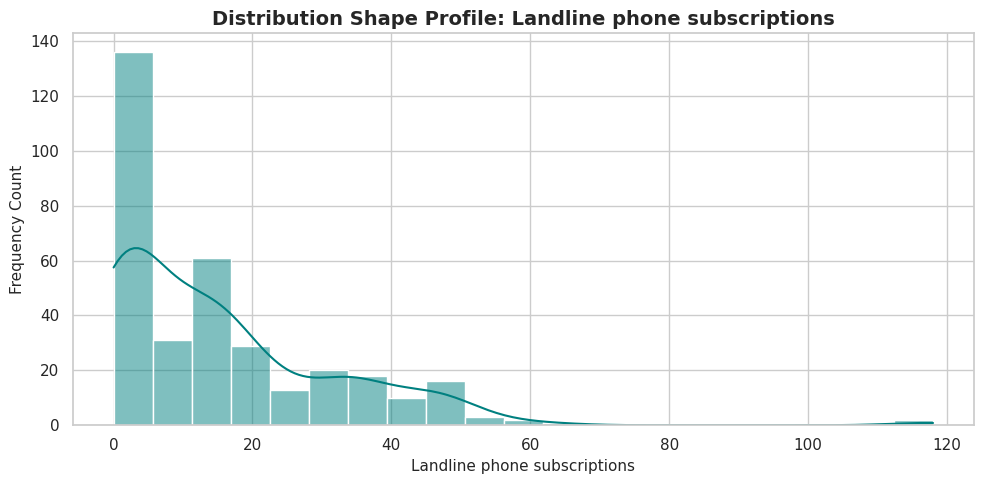

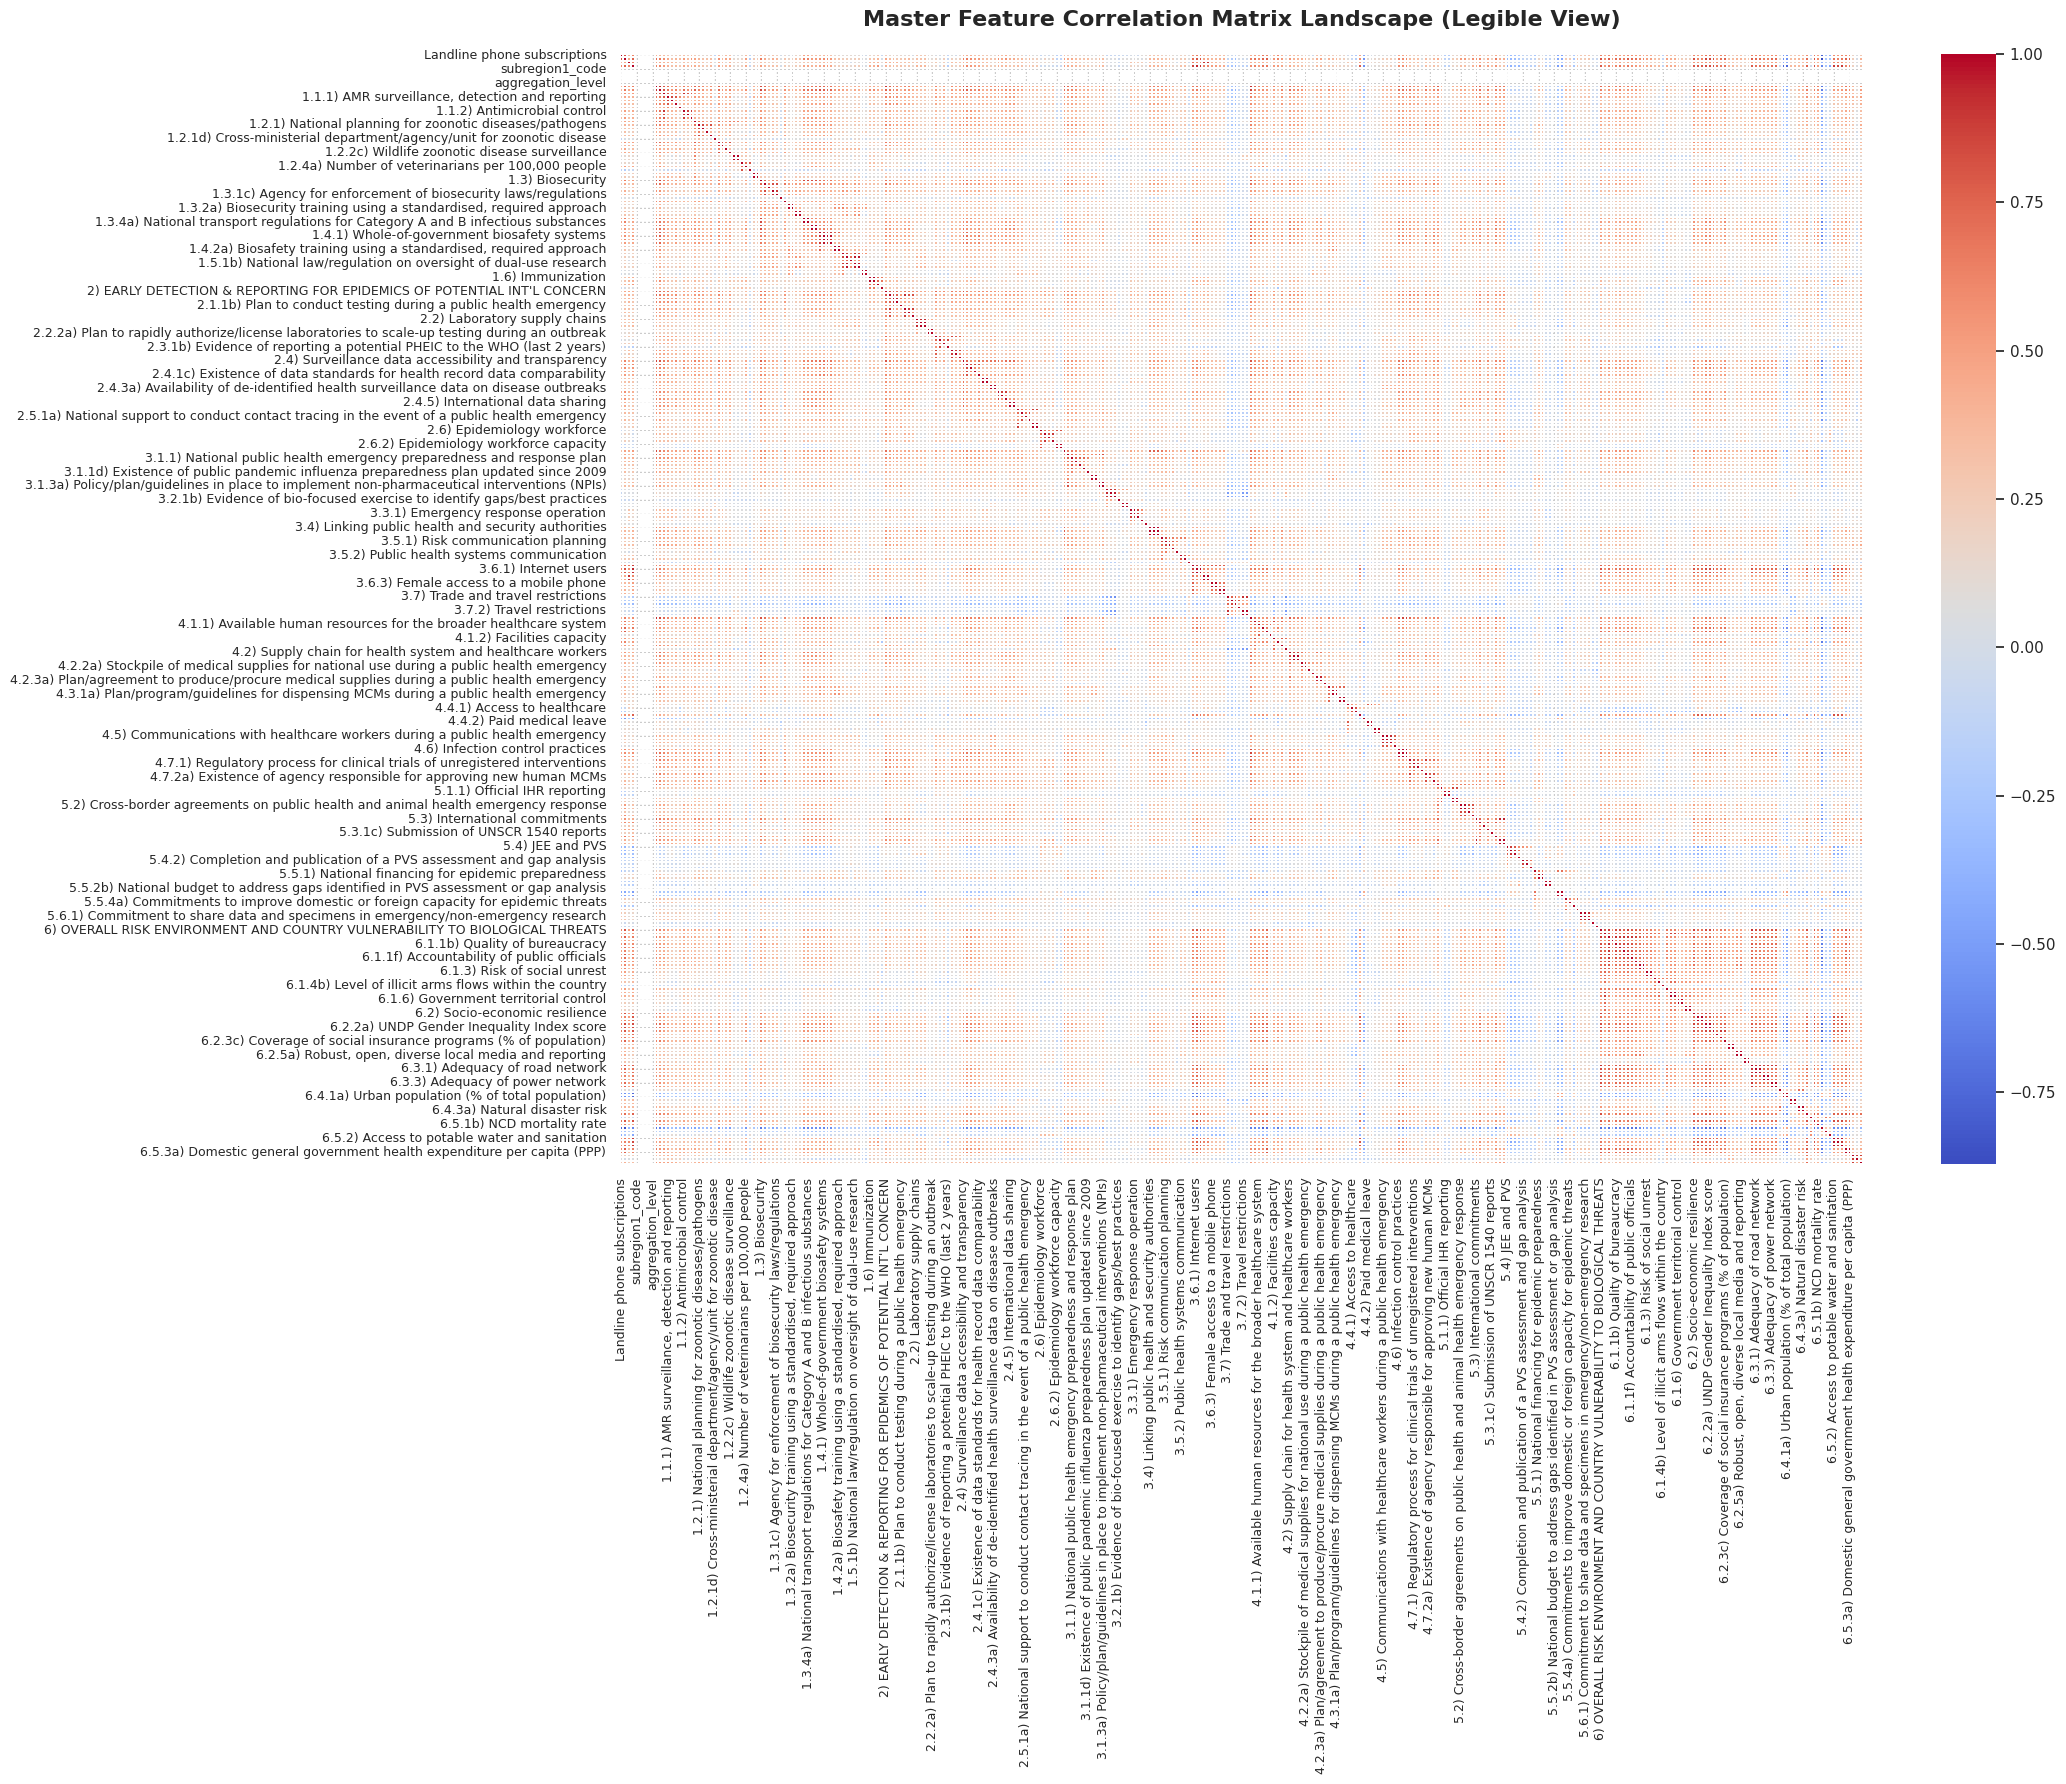

In [ ]:

# ==========================================
# EDA for "ICT_GHS_Ind_md.csv" table
# ==========================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SET UP WORKSPACE PATHS & LOAD DATA
# ==========================================
data_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
target_file = "ICT_GHS_Ind_md.csv"
path_target = os.path.join(data_dir, target_file)

if not os.path.exists(path_target):
    raise FileNotFoundError(f"❌ Error: Missing file '{target_file}'. Please verify the path.")

df = pd.read_csv(path_target)
df.columns = df.columns.str.strip()

print(f"📊 Dataset successfully loaded for Comprehensive EDA. Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Isolate numerical metrics for calculation, ignoring structural tracking columns
exclude_keys = ['country_name', 'Country', 'location_key', 'country_code', 'Year']
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in exclude_keys]

# ==========================================
# 2. RUN STATISTICAL DIAGNOSTICS (THE MATH)
# ==========================================
print("="*75)
print("📈 SKEWNESS & SHAPE ANALYSIS")
print("="*75)
for col in numeric_cols:
    skew_val = df[col].skew()
    if pd.isna(skew_val):
        continue
    if abs(skew_val) > 1.0:
        print(f"  ⚠️ '{col}': Highly Skewed (Skew: {skew_val:.4f}) -> Candidate for pipeline log-transformation.")
    else:
        print(f"  ✅ '{col}': Normal/Symmetric Shape (Skew: {skew_val:.4f})")

if len(numeric_cols) > 1:
    corr_matrix = df[numeric_cols].corr()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr = [(col, row, upper_tri[col][row]) for col in upper_tri.columns for row in upper_tri.index if abs(upper_tri[col][row]) > 0.85]

    print("\n" + "="*75)
    print("🚨 SEVERE MULTICOLLINEARITY DETECTED (|r| > 0.85)")
    print("="*75)
    if high_corr:
        for f1, f2, r_val in high_corr:
            print(f"  ⚠️ Redundant Columns: [{f1}] and [{f2}] have a strong linear match (r = {r_val:.4f})")
    else:
        print("  ✅ All feature variance columns have clean, independent distributions.")

# ==========================================
# 3. GENERATE VISUAL PLOTS (THE GRAPHICS)
# ==========================================
print("\n🎨 Spawning optimized visual distributions and heatmaps...")
sns.set_theme(style="whitegrid")

# Plot A: Stand-alone distribution profile for the primary metric
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x=numeric_cols[0], kde=True, color="teal")
plt.title(f"Distribution Shape Profile: {numeric_cols[0]}", fontsize=14, fontweight='bold')
plt.xlabel(numeric_cols[0], fontsize=11)
plt.ylabel("Frequency Count", fontsize=11)
plt.tight_layout()
plt.show()

# Plot B: High-Resolution Heatmap Canvas with text overlap prevention
if len(numeric_cols) > 1:
    plt.figure(figsize=(22, 18))
    # annot=False stops overlapping numbers from crashing into each other
    sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.1, cbar=True)
    plt.title("Master Feature Correlation Matrix Landscape (Legible View)", fontsize=16, fontweight='bold', pad=20)
    plt.xticks(rotation=90, fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()

📊 Dataset 'health_Ind_md.csv' successfully loaded. Shape: 210 rows, 21 columns

📈 HEALTHCARE INDICATORS SKEWNESS PROFILE
  ✅ 'aggregation_level': Symmetric/Normal (Skew: 0.0000)
  ✅ 'life_expectancy': Symmetric/Normal (Skew: -0.5808)
  ✅ 'smoking_prevalence': Symmetric/Normal (Skew: 0.2886)
  ⚠️ 'diabetes_prevalence': Highly Skewed (Skew: 1.3859) -> Consider normalization or logging.
  ⚠️ 'infant_mortality_rate': Highly Skewed (Skew: 1.1521) -> Consider normalization or logging.
  ✅ 'adult_male_mortality_rate': Symmetric/Normal (Skew: 0.8509)
  ⚠️ 'adult_female_mortality_rate': Highly Skewed (Skew: 1.2224) -> Consider normalization or logging.
  ✅ 'pollution_mortality_rate': Symmetric/Normal (Skew: 0.8547)
  ✅ 'comorbidity_mortality_rate': Symmetric/Normal (Skew: 0.0192)
  ⚠️ 'hospital_beds_per_1000': Highly Skewed (Skew: 1.6180) -> Consider normalization or logging.
  ⚠️ 'nurses_per_1000': Highly Skewed (Skew: 1.3995) -> Consider normalization or logging.
  ✅ 'physicians_per_1000': Sy

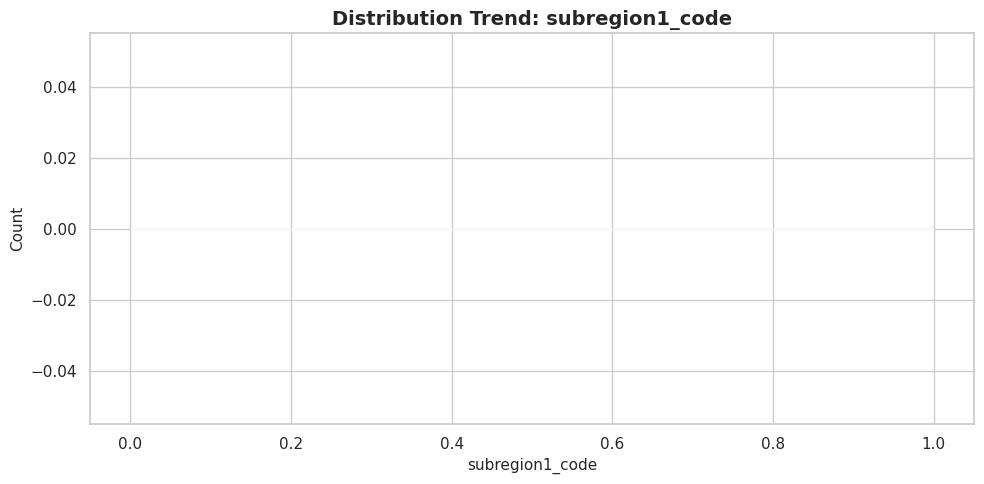

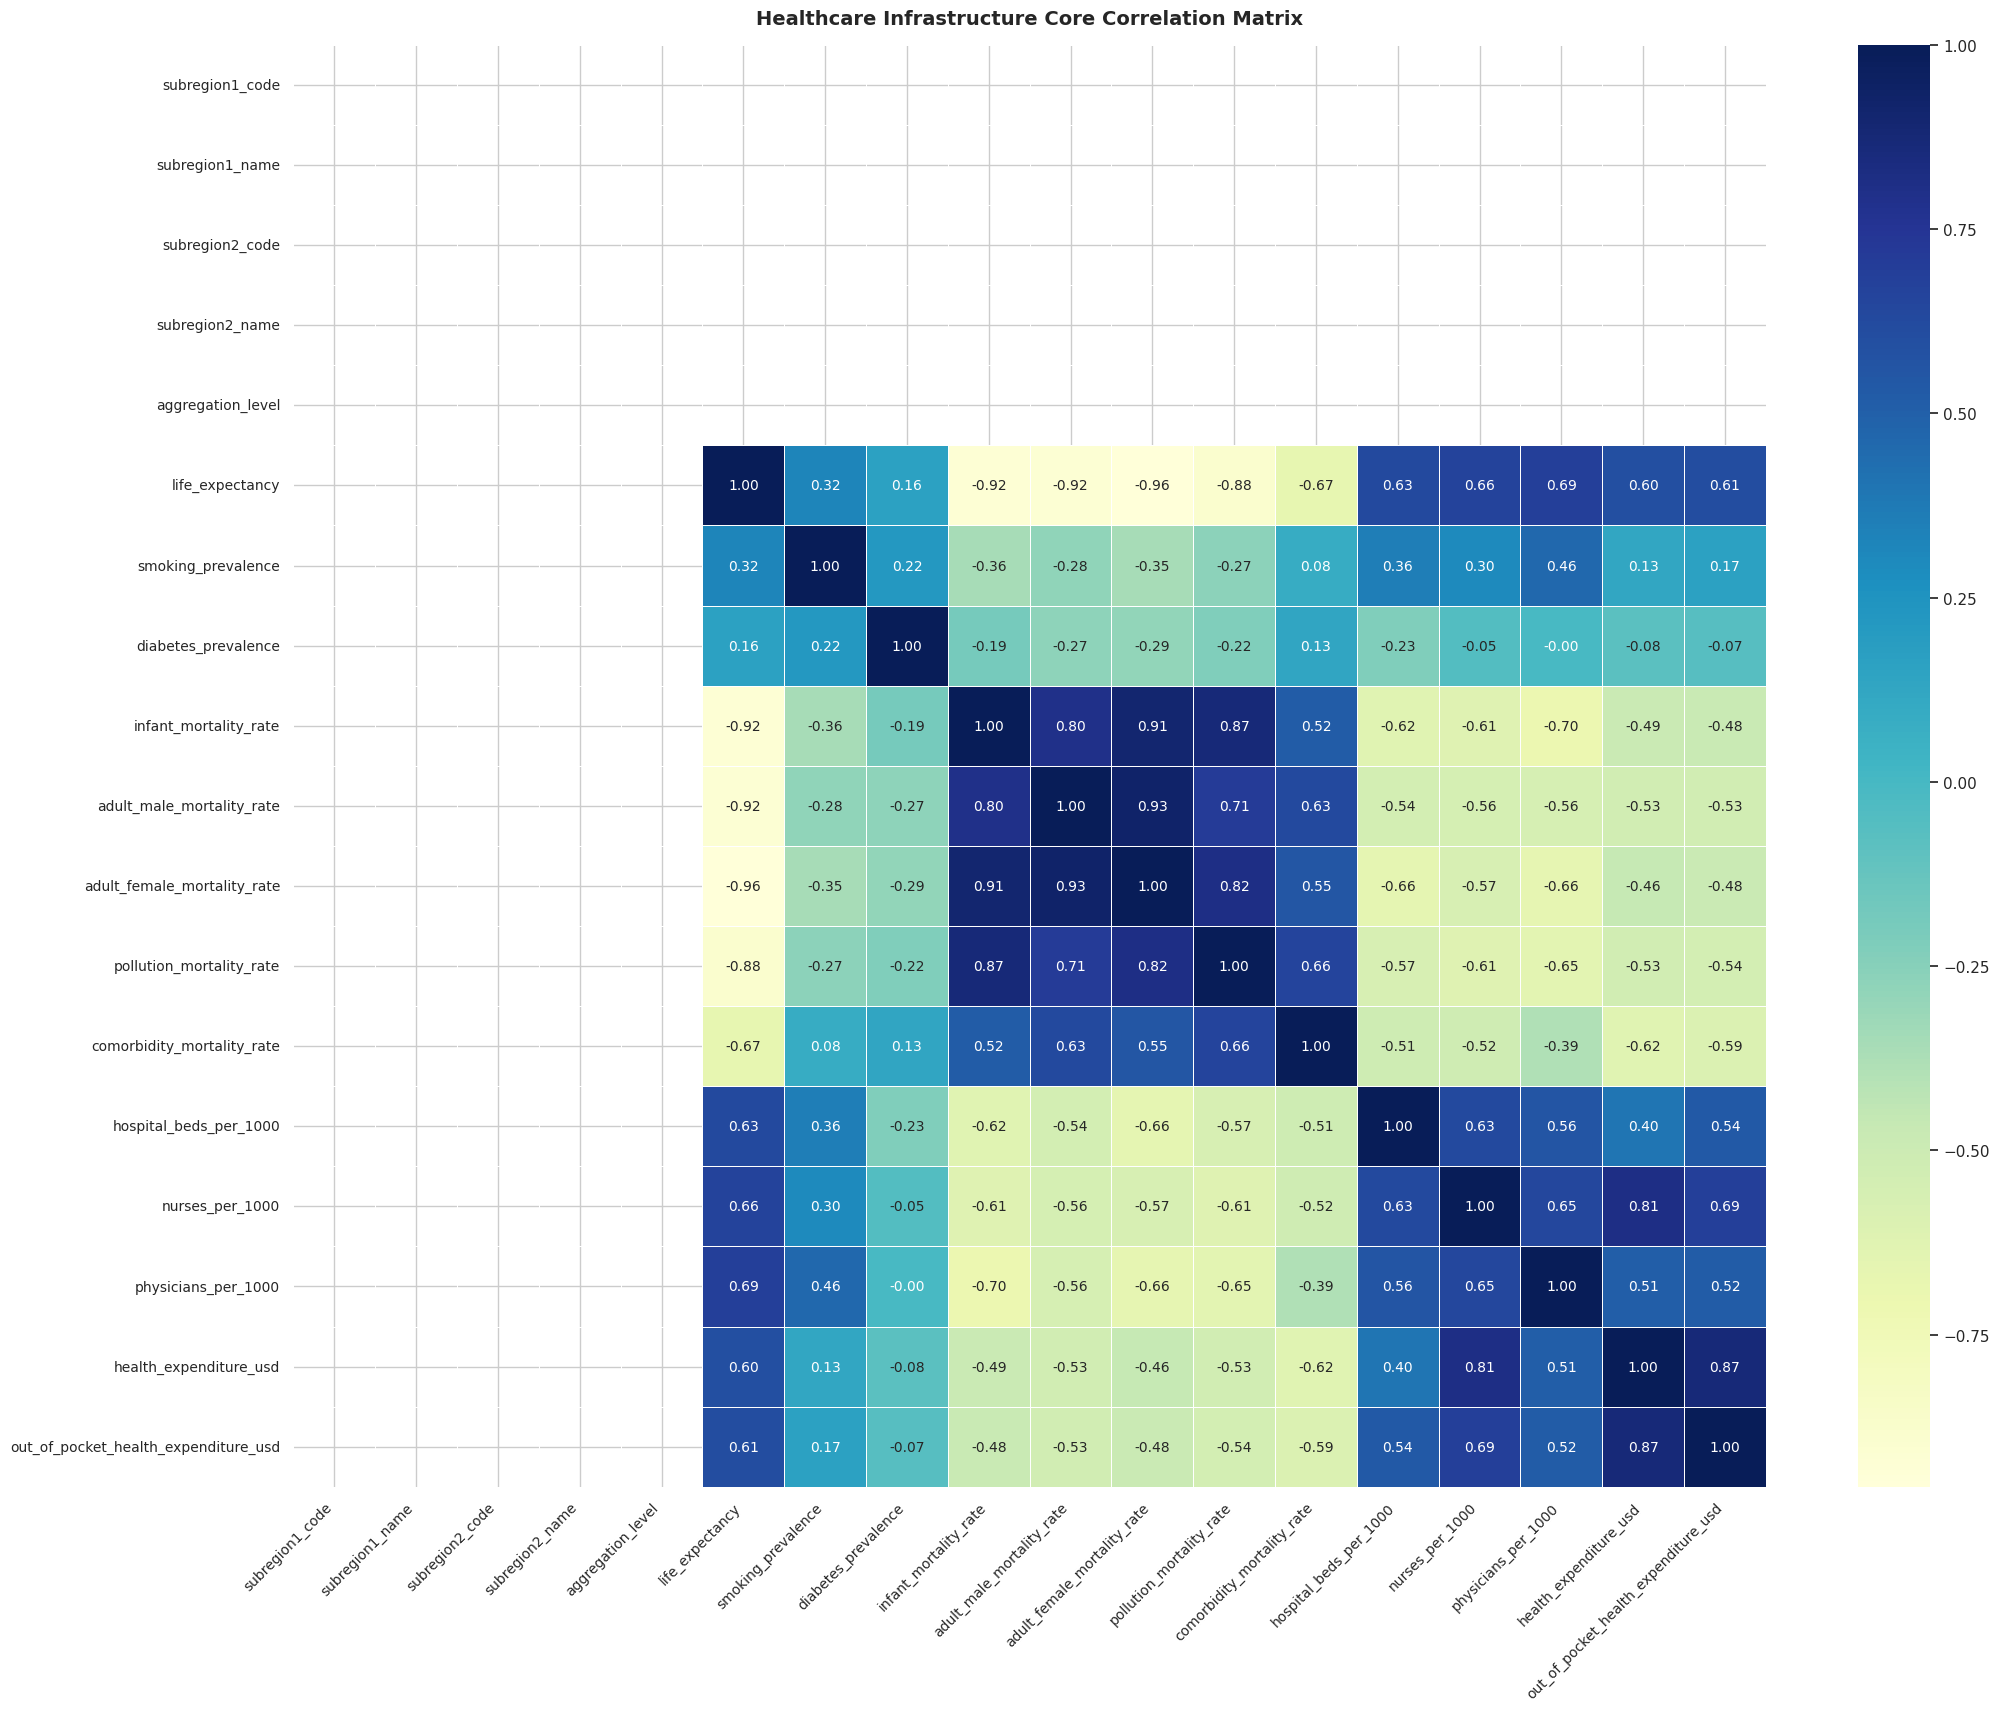

In [ ]:

# ==========================================
# EDA for "health_Ind_md.csv" table
# ==========================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SET UP WORKSPACE PATHS & LOAD DATA
# ==========================================
data_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
target_file = "health_Ind_md.csv"
path_target = os.path.join(data_dir, target_file)

if not os.path.exists(path_target):
    raise FileNotFoundError(f"❌ Error: Missing file '{target_file}'. Please verify your directory paths.")

df_health = pd.read_csv(path_target)
df_health.columns = df_health.columns.str.strip()

print(f"📊 Dataset '{target_file}' successfully loaded. Shape: {df_health.shape[0]} rows, {df_health.shape[1]} columns\n")

# Isolate analytical numeric metrics, ignoring tracking indices
exclude_keys = ['country_name', 'Country', 'location_key', 'country_code', 'Year']
numeric_cols = [col for col in df_health.select_dtypes(include=[np.number]).columns if col not in exclude_keys]

# ==========================================
# 2. RUN STATISTICAL DIAGNOSTICS (THE MATH)
# ==========================================
print("="*75)
print("📈 HEALTHCARE INDICATORS SKEWNESS PROFILE")
print("="*75)
for col in numeric_cols:
    skew_val = df_health[col].skew()
    if pd.isna(skew_val):
        continue
    if abs(skew_val) > 1.0:
        print(f"  ⚠️ '{col}': Highly Skewed (Skew: {skew_val:.4f}) -> Consider normalization or logging.")
    else:
        print(f"  ✅ '{col}': Symmetric/Normal (Skew: {skew_val:.4f})")

if len(numeric_cols) > 1:
    corr_matrix = df_health[numeric_cols].corr()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr = [(col, row, upper_tri[col][row]) for col in upper_tri.columns for row in upper_tri.index if abs(upper_tri[col][row]) > 0.85]

    print("\n" + "="*75)
    print("🚨 RELEVANT MULTICOLLINEARITY (r > 0.85)")
    print("="*75)
    if high_corr:
        for f1, f2, r_val in high_corr:
            print(f"  ⚠️ High Interaction: [{f1}] & [{f2}] (r = {r_val:.2f})")
    else:
        print("  ✅ Infrastructure variance vectors are independent and safe for models.")

# ==========================================
# 3. GENERATE OPTIMIZED PLOTS (THE GRAPHICS)
# ==========================================
print("\n🎨 Spawning clean visual diagnostic plots...")
sns.set_theme(style="whitegrid")

# Plot A: Stand-alone healthcare baseline metric distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=df_health, x=numeric_cols[0], kde=True, color="crimson")
plt.title(f"Distribution Trend: {numeric_cols[0]}", fontsize=14, fontweight='bold')
plt.xlabel(numeric_cols[0], fontsize=11)
plt.ylabel("Count", fontsize=11)
plt.tight_layout()
plt.show()

# Plot B: Dynamically sized legible heatmap
if len(numeric_cols) > 1:
    # Dynamically scale the figure canvas size based on the number of features present
    canvas_size = max(10, len(numeric_cols) * 1.2)
    plt.figure(figsize=(canvas_size, canvas_size * 0.8))

    # annot=True is enabled here since health indicators are typically smaller in number than GHS
    sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5,
                cbar=True, annot_kws={"size": 10})

    plt.title("Healthcare Infrastructure Core Correlation Matrix", fontsize=14, fontweight='bold', pad=15)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()